In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

I0000 00:00:1781075222.445156   13404 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781075243.416562   13404 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781075252.729185   13404 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [3]:
crop = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/Crop_recommendation.csv")

X = crop.drop("label", axis=1)
y = crop["label"]

In [4]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of Classes:", len(label_encoder.classes_))

Number of Classes: 22


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [7]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [8]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(7,)))

model.add(Dense(32, activation='relu'))

model.add(Dense(22, activation='softmax'))

/workspaces/farmer_crop_climate_mismatch_system/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781075255.829524   13404 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(7,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(22, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
print("Starting training...")

history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Starting training...
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2912 - loss: 2.7444 - val_accuracy: 0.4801 - val_loss: 2.2778
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5760 - loss: 1.7162 - val_accuracy: 0.7102 - val_loss: 1.1627
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8381 - loss: 0.7792 - val_accuracy: 0.8722 - val_loss: 0.5566
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9311 - loss: 0.3990 - val_accuracy: 0.9205 - val_loss: 0.3356
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9496 - loss: 0.2573 - val_accuracy: 0.9318 - val_loss: 0.2408
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9553 - loss: 0.1832 - val_accuracy: 0.9460 - val_loss: 0.1899
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9638 - loss: 0.1458 - val_accuracy: 0.9631 - val_loss: 0.1494
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9680 - loss: 0.1207 - val

In [12]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9659 - loss: 0.1344  
Accuracy: 0.9659090638160706


In [13]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Neural Network Accuracy:", round(accuracy * 100, 2), "%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9659 - loss: 0.1344 
Neural Network Accuracy: 96.59 %


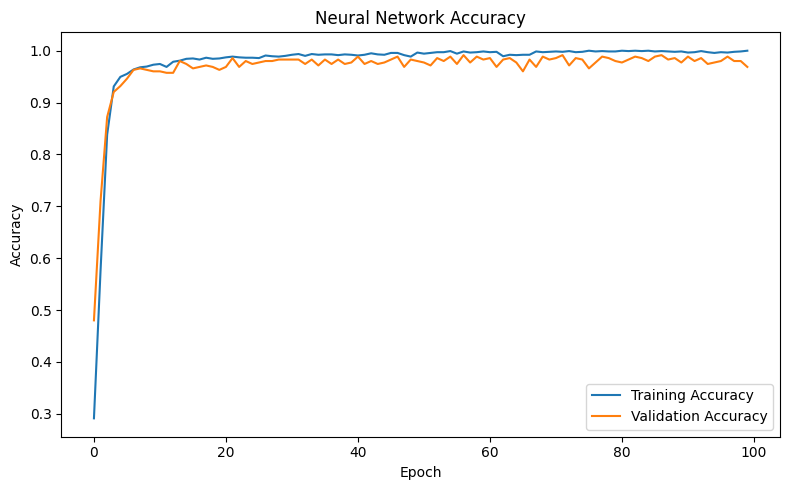

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.tight_layout()

plt.savefig("../screenshots/neural_network_training.png")

plt.show()

In [15]:
import pandas as pd

rainfall = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/district wise rainfall normal.csv")

In [16]:
print(rainfall["STATE_UT_NAME"].nunique())
print(rainfall["DISTRICT"].nunique())

print(rainfall[["STATE_UT_NAME","DISTRICT","ANNUAL"]].head())

35
637
                 STATE_UT_NAME       DISTRICT  ANNUAL
0  ANDAMAN And NICOBAR ISLANDS        NICOBAR  2805.2
1  ANDAMAN And NICOBAR ISLANDS  SOUTH ANDAMAN  3015.7
2  ANDAMAN And NICOBAR ISLANDS  N & M ANDAMAN  2913.3
3            ARUNACHAL PRADESH          LOHIT  3043.8
4            ARUNACHAL PRADESH     EAST SIANG  4034.7


In [17]:
model.save("models/neural_network_model.h5")

In [18]:
import joblib

In [19]:
joblib.dump(
    scaler,
    "../models/neural_network_scaler.pkl"
)

joblib.dump(
    label_encoder,
    "../models/neural_network_label_encoder.pkl"
)

print("Scaler and Label Encoder saved successfully!")

Scaler and Label Encoder saved successfully!


In [20]:
print(X.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
